# 🏥 LLM Medical Pipeline — Llama 3.1 8B sur Kaggle T4
**Pipeline complet** : Chargement GGUF → Prompt médical → JSON structuré → Sauvegarde incrémentale

> ⚠️ Avant de lancer : activer le GPU T4 dans *Settings → Accelerator → GPU T4 x1*

## Cellule 1 — Installation des dépendances

In [37]:
# ============================================================
# CELLULE 1 — Installation des dépendances
# À exécuter UNE SEULE FOIS par session Kaggle.
# llama-cpp-python est compilé avec le support CUDA pour
# exploiter le GPU T4 et accélérer l'inférence.
# ============================================================

# 1. Variables d'environnement CUDA pour la compilation
import os
os.environ["CMAKE_ARGS"]    = "-DGGML_CUDA=on"
os.environ["FORCE_CMAKE"]   = "1"
os.environ["CUDA_DOCKER_ARCH"] = "sm_75"  # Architecture Turing du T4

# 2. Installation llama-cpp-python (avec CUDA) + utilitaires
!pip install --quiet --upgrade pip
!pip install --quiet llama-cpp-python \
    --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121
!pip install --quiet huggingface_hub tqdm pandas

print('✅ Dépendances installées avec succès')

✅ Dépendances installées avec succès


## Cellule 2 — Téléchargement du modèle GGUF

In [38]:
# ============================================================
# CELLULE 2 — Téléchargement du modèle GGUF depuis HuggingFace
# Le fichier Q4_K_M offre le meilleur compromis
# vitesse / qualité pour un T4 (16 Go VRAM).
# Taille : ~4.9 Go — téléchargé dans /kaggle/working/models/
# ============================================================

from huggingface_hub import hf_hub_download
import os

MODEL_REPO = "featherless-ai-quants/meta-llama-Meta-Llama-3.1-8B-Instruct-GGUF"
MODEL_FILE = "meta-llama-Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf"
MODEL_DIR  = "/kaggle/working/models"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_FILE)

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(MODEL_PATH):
    print(f'✅ Modèle déjà présent : {MODEL_PATH}')
else:
    print('⬇️  Téléchargement du modèle GGUF (~4.9 Go)...')
    MODEL_PATH = hf_hub_download(
        repo_id=MODEL_REPO,
        filename=MODEL_FILE,
        local_dir=MODEL_DIR,
        local_dir_use_symlinks=False,
    )
    print(f'✅ Modèle téléchargé : {MODEL_PATH}')

✅ Modèle déjà présent : /kaggle/working/models/meta-llama-Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf


## Cellule 3 — Chargement du modèle en mémoire GPU

In [39]:
# ============================================================
# CELLULE 3 — Chargement du modèle avec llama-cpp-python
#
# Paramètres clés pour le T4 :
#   n_gpu_layers=-1  → toutes les couches sur GPU (VRAM T4 = 16 Go)
#   n_ctx=4096       → fenêtre de contexte (note + question)
#   n_batch=512      → taille des batches de tokens (performance)
#   verbose=False    → masquer les logs de llama.cpp
# ============================================================

from llama_cpp import Llama

print('🔄 Chargement du modèle en VRAM GPU...')

llm = Llama(
    model_path=MODEL_PATH,
    n_gpu_layers=-1,      # Décharger TOUTES les couches sur le GPU T4
    n_ctx=4096,           # Contexte max (note clinique longue ~2-3k tokens)
    n_batch=512,          # Taille de batch pour l'inférence
    n_threads=4,          # Threads CPU pour les couches hors-GPU
    seed=42,              # Reproductibilité
    verbose=False,        # Masquer les logs bas niveau
)

print('✅ Modèle chargé en mémoire GPU')
print(f'   Contexte max : {llm.n_ctx()} tokens')

🔄 Chargement du modèle en VRAM GPU...


llama_context: n_ctx_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


✅ Modèle chargé en mémoire GPU
   Contexte max : 4096 tokens


## Cellule 4 — Template de prompt et fonctions utilitaires

In [40]:
# ============================================================
# CELLULE 4 — Template de prompt et fonctions utilitaires
# ============================================================

import json

# ── Template de prompt ──────────────────────────────────────
PROMPT_TEMPLATE = """\
You are an AI medical expert. Your role is to analyze the clinical note \
to extract a comprehensive and structured medical report, and then write \
a precise summary answering the question.

[CONTEXT]
Clinical note: {note}
Question: {question}

[OUTPUT INSTRUCTIONS]
You must respond EXCLUSIVELY with a valid JSON object. \
Do not skip lines before and do not add any explanatory text.

Golden rule: If information is not EXPLICITLY mentioned in \
the text, you must write \"Not mentioned\" (for text fields) or [] (for \
empty lists). Never invent data, medications, or diagnoses.

The JSON format must STRICTLY be the following:
{{
    \"patient_id\": \"{patient_id}\",
    \"demographics\": {{
        \"age\": \"Age or 'Not mentioned'\",
        \"gender\": \"Gender or 'Not mentioned'\"
    }},
    \"clinical_data\": {{
        \"analyses_performed\": [\"List of tests performed\" or []],
        \"past_medications\": [\"Medications prior to admission\" or []],
        \"hospital_treatments\": [\"Treatments during the stay\" or []],
        \"future_plan\": [\"Discharge prescriptions, follow-up\" or []]
    }},
    \"summary\": \"Targeted summary answering the question\"
}}
"""

# ── Constantes de configuration ─────────────────────────────
MAX_NOTE_CHARS   = 3000   # Troncature des notes trop longues (limite contexte)
MAX_NEW_TOKENS   = 800    # Tokens max de la réponse JSON
TEMPERATURE      = 0.1    # Faible température → réponses factuelles, peu d'hallucination
SAVE_EVERY_N     = 100    # Sauvegarde incrémentale toutes les N lignes
OUTPUT_TEMP_PATH = "/kaggle/working/output_temporaire.csv"
OUTPUT_FINAL_PATH= "/kaggle/working/output_final.csv"

# ── Fonction de génération pour une ligne ───────────────────
def generate_medical_json(row) -> str:
    """
    Envoie note + question au LLM et retourne un JSON string.
    
    Utilise create_chat_completion avec response_format='json_object'
    pour forcer nativement une sortie JSON valide (grammar sampling).
    
    Returns:
        str — JSON valide ou JSON d'erreur signalant l'échec
    """
    # Troncature de sécurité pour les notes très longues
    note_truncated = str(row['note'])[:MAX_NOTE_CHARS]
    
    prompt = PROMPT_TEMPLATE.format(
        note=note_truncated,
        question=str(row['question']),
        patient_id=str(row['patient_id']),
    )
    
    response = llm.create_chat_completion(
        messages=[
            {
                "role": "system",
                "content": "Tu es un assistant médical expert. Tu réponds UNIQUEMENT en JSON valide."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        response_format={"type": "json_object"},  # JSON grammar sampling natif
        max_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
        top_p=0.9,
        repeat_penalty=1.1,   # Pénalise les répétitions
    )
    
    # Extraire le contenu texte de la réponse
    raw_json_str = response['choices'][0]['message']['content']
    
    # Vérification : parser pour s'assurer que c'est un JSON valide
    json.loads(raw_json_str)  # Lève ValueError si invalide
    
    return raw_json_str

print('✅ Template de prompt et fonctions prêts')
print(f'   Troncature notes    : {MAX_NOTE_CHARS} caractères max')
print(f'   Tokens réponse max  : {MAX_NEW_TOKENS}')
print(f'   Température         : {TEMPERATURE}')
print(f'   Sauvegarde toutes   : {SAVE_EVERY_N} lignes')

✅ Template de prompt et fonctions prêts
   Troncature notes    : 3000 caractères max
   Tokens réponse max  : 800
   Température         : 0.1
   Sauvegarde toutes   : 100 lignes


## Cellule 5 — Test sur 1 ligne (vérification avant batch)

In [41]:
# ============================================================
# CELLULE 5 — Test rapide sur 1 ligne
# À exécuter AVANT le pipeline complet pour valider
# que le modèle génère bien du JSON au format attendu.
# ============================================================

import pandas as pd
import json

df = pd.read_csv('/kaggle/input/datasets/mdamineelarbani/qa-datset-prombt-engineering/QA_dataset.csv')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes : {df.columns.tolist()}')
print()

# Test sur la première ligne
test_row = df.iloc[0]
print(f'🧪 Test sur patient_id={test_row["patient_id"]}')
print(f'   Note (début) : {str(test_row["note"])[:150]}...')
print(f'   Question     : {test_row["question"]}')
print()

try:
    result = generate_medical_json(test_row)
    parsed = json.loads(result)
    print('✅ JSON généré et validé avec succès :')
    print(json.dumps(parsed, indent=2, ensure_ascii=False))
except Exception as e:
    print(f'❌ Échec du test : {e}')

Dataset chargé : 1,500 lignes × 6 colonnes
Colonnes : ['Unnamed: 0', 'patient_id', 'note', 'question', 'answer', 'task']

🧪 Test sur patient_id=2
   Note (début) : Hospital Course Summary: Admission Date: [Insert date] Discharge Date: [Insert date] Patient: [Patient's Name] Sex: Male Age: 57 years Admission Diagn...
   Question     : What were the key improvements in the patient's medical condition during the hospital course, and how was physical therapy utilized to achieve these results?

✅ JSON généré et validé avec succès :
{
  "patient_id": "1",
  "demographics": {
    "age": "57 years",
    "gender": "Male"
  },
  "clinical_data": {
    "analyses_performed": [],
    "past_medications": [],
    "hospital_treatments": [
      "Physical therapy",
      "Positioning",
      "Oxygen therapy"
    ],
    "future_plan": [
      "Continue physical rehabilitation at home"
    ]
  },
  "summary": "The key improvements in the patient's medical condition during the hospital course were a signi

## Cellule 6 — Pipeline principal avec sauvegarde incrémentale

In [42]:
# ============================================================
# CELLULE 6 — Pipeline principal
#
# Stratégie de robustesse :
#   1. Reprise automatique depuis output_temporaire.csv
#      si la session Kaggle a planté → on ne retraite pas
#      les lignes déjà traitées.
#   2. try/except par ligne → une erreur n'arrête pas le pipeline.
#   3. Sauvegarde toutes les SAVE_EVERY_N lignes.
#   4. Barre tqdm avec ETA et stats d'erreur en temps réel.
# ============================================================

import pandas as pd
import json
import os
from tqdm.notebook import tqdm

# ── 1. Chargement du dataset source ─────────────────────────
df = pd.read_csv('/kaggle/input/datasets/mdamineelarbani/qa-datset-prombt-engineering/QA_dataset.csv')
print(f'📂 Dataset source chargé : {df.shape[0]:,} lignes')

# ── 2. Reprise depuis sauvegarde intermédiaire ───────────────
if os.path.exists(OUTPUT_TEMP_PATH):
    df_temp = pd.read_csv(OUTPUT_TEMP_PATH)
    already_done = set(df_temp['patient_id'].astype(str).tolist())
    print(f'♻️  Reprise détectée : {len(already_done):,} lignes déjà traitées dans {OUTPUT_TEMP_PATH}')
    print(f'   Lignes restantes : {df.shape[0] - len(already_done):,}')
    # Récupérer les résultats déjà calculés
    results_dict = dict(zip(df_temp['patient_id'].astype(str), df_temp['llm_response']))
else:
    already_done  = set()
    results_dict  = {}
    print('🆕 Aucune sauvegarde trouvée, démarrage depuis le début')

# ── 3. Compteurs pour les stats ──────────────────────────────
n_success = 0
n_errors  = 0

# ── 4. Boucle principale ─────────────────────────────────────
for i, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc='🔄 Traitement médical',
    unit='doc',
    dynamic_ncols=True,
):
    pid = str(row['patient_id'])
    
    # Ignorer les lignes déjà traitées (mode reprise)
    if pid in already_done:
        continue
    
    # ── Appel LLM avec gestion d'erreur robuste ──────────────
    try:
        llm_response = generate_medical_json(row)
        n_success += 1
    
    except ValueError as ve:
        # JSON invalide retourné par le modèle (rare avec json_object)
        llm_response = json.dumps({
            "erreur": "json_invalide",
            "patient_id": pid,
            "detail": str(ve)[:200]
        }, ensure_ascii=False)
        n_errors += 1
    
    except MemoryError:
        # Rare mais possible si la note est extrêmement longue
        llm_response = json.dumps({
            "erreur": "memoire_insuffisante",
            "patient_id": pid
        }, ensure_ascii=False)
        n_errors += 1
    
    except Exception as e:
        # Toute autre erreur (timeout, crash llama.cpp, etc.)
        llm_response = json.dumps({
            "erreur": "generation_echouee",
            "patient_id": pid,
            "detail": str(e)[:200]
        }, ensure_ascii=False)
        n_errors += 1
    
    # ── Stocker le résultat ──────────────────────────────────
    results_dict[pid] = llm_response
    already_done.add(pid)
    
    # ── Sauvegarde incrémentale toutes les N lignes ──────────
    if len(already_done) % SAVE_EVERY_N == 0:
        df_partial = df[df['patient_id'].astype(str).isin(already_done)].copy()
        df_partial['llm_response'] = df_partial['patient_id'].astype(str).map(results_dict)
        df_partial.to_csv(OUTPUT_TEMP_PATH, index=False)
        tqdm.write(f'💾 Sauvegarde intermédiaire : {len(already_done):,} lignes → {OUTPUT_TEMP_PATH}')
        tqdm.write(f'   ✅ Succès: {n_success} | ❌ Erreurs: {n_errors}')

# ── 5. Sauvegarde finale ─────────────────────────────────────
df['llm_response'] = df['patient_id'].astype(str).map(results_dict)
df.to_csv(OUTPUT_FINAL_PATH, index=False)

print()
print('=' * 55)
print('🎉 PIPELINE TERMINÉ')
print(f'   Lignes traitées : {len(already_done):,} / {df.shape[0]:,}')
print(f'   ✅ Succès        : {n_success:,}')
print(f'   ❌ Erreurs       : {n_errors:,}')
print(f'   Taux de succès  : {n_success / max(n_success + n_errors, 1) * 100:.1f}%')
print(f'   Fichier final   : {OUTPUT_FINAL_PATH}')
print('=' * 55)

📂 Dataset source chargé : 1,500 lignes
🆕 Aucune sauvegarde trouvée, démarrage depuis le début


🔄 Traitement médical:   0%|          | 0/1500 [00:00<?, ?doc/s]

💾 Sauvegarde intermédiaire : 100 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 100 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 200 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 200 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 300 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 300 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 400 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 400 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 500 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 500 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 600 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 600 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 700 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 700 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 800 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 800 | ❌ Erreurs: 0
💾 Sauvegarde intermédiaire : 900 lignes → /kaggle/working/output_temporaire.csv
   ✅ Succès: 900 | ❌ Err

## Cellule 7 — Vérification et analyse des résultats

In [43]:
# ============================================================
# CELLULE 7 — Vérification des résultats
# Analyse qualité : taux d'erreurs, champs manquants,
# et extraction des colonnes JSON en colonnes pandas.
# ============================================================

import pandas as pd
import json

df_out = pd.read_csv(OUTPUT_FINAL_PATH)
print(f'📂 Fichier chargé : {df_out.shape[0]:,} lignes')

# ── Parsing des JSON pour validation ────────────────────────
def safe_parse_json(json_str):
    try:
        return json.loads(json_str)
    except:
        return None

df_out['llm_parsed'] = df_out['llm_response'].apply(safe_parse_json)

n_total   = len(df_out)
n_valid   = df_out['llm_parsed'].notna().sum()
n_errors  = df_out['llm_parsed'].apply(
    lambda x: 'erreur' in x if isinstance(x, dict) else False
).sum()

print(f'\n=== Rapport qualité ===')
print(f'  JSON valides      : {n_valid:,} / {n_total:,} ({n_valid/n_total*100:.1f}%)')
print(f'  Lignes avec erreur: {n_errors:,} ({n_errors/n_total*100:.1f}%)')
print(f'  JSON malformés    : {n_total - n_valid:,}')

# ── Extraction des champs JSON en colonnes plates ─────────
def extract_field(parsed, *keys):
    """Navigation sécurisée dans un dict imbriqué."""
    try:
        val = parsed
        for k in keys:
            val = val[k]
        return val
    except:
        return None

valid_mask = df_out['llm_parsed'].notna()
df_out.loc[valid_mask, 'age']       = df_out.loc[valid_mask, 'llm_parsed'].apply(lambda x: extract_field(x, 'demographics', 'age'))
df_out.loc[valid_mask, 'gender']    = df_out.loc[valid_mask, 'llm_parsed'].apply(lambda x: extract_field(x, 'demographics', 'gender'))
df_out.loc[valid_mask, 'summary_llm'] = df_out.loc[valid_mask, 'llm_parsed'].apply(lambda x: extract_field(x, 'summary'))

# Nettoyage : retirer la colonne intermédiaire
df_out = df_out.drop(columns=['llm_parsed'])

# Sauvegarde enrichie
ENRICHED_PATH = '/kaggle/working/output_enrichi.csv'
df_out.to_csv(ENRICHED_PATH, index=False)
print(f'\n✅ Fichier enrichi sauvegardé : {ENRICHED_PATH}')

# Aperçu
print('\n=== Aperçu des 3 premières lignes ===')
df_out[['patient_id', 'question', 'age', 'gender', 'summary_llm']].head(3)

📂 Fichier chargé : 1,500 lignes

=== Rapport qualité ===
  JSON valides      : 1,500 / 1,500 (100.0%)
  Lignes avec erreur: 0 (0.0%)
  JSON malformés    : 0

✅ Fichier enrichi sauvegardé : /kaggle/working/output_enrichi.csv

=== Aperçu des 3 premières lignes ===


,patient_id,question,age,gender,summary_llm
0,2,What were the key improvements in the patient'...,57 years,Male,The key improvements in the patient's medical ...
1,5,How did the patient's treatment for dysphagia ...,52,Male,The patient's treatment for dysphagia progress...
2,11,"Can you provide a summary of the treatment, ho...",45 years,Female,A 45-year-old female patient with a history of...


In [44]:
# ============================================================
# CELLULE 1 — Installation
# rouge-score  : ROUGE-1, ROUGE-2, ROUGE-L (Google)
# bert-score   : BERTScore-F1 (Microsoft)
# transformers : modèle d'embedding pour BERTScore
# ============================================================

!pip install --quiet rouge-score bert-score transformers
print('✅ Dépendances installées')

✅ Dépendances installées


### Chargement du fichier et extraction du champ `summary`

In [45]:
# ============================================================
# CELLULE 2 — Chargement du CSV et extraction du summary
# ============================================================

import pandas as pd
import json
import re

INPUT_PATH  = '/kaggle/working/output_final.csv'   # ← adapter si besoin
OUTPUT_PATH = '/kaggle/working/output_final.csv'   # on écrase en place

df = pd.read_csv(INPUT_PATH)
print(f'📂 Fichier chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Colonnes        : {df.columns.tolist()}')

# ── Extraction du champ 'summary' depuis llm_response (JSON) ──
def extract_summary(llm_response_str):
    """
    Parse la colonne llm_response (JSON string) et retourne
    le champ 'summary'. Retourne chaîne vide si parsing échoue
    ou si la ligne contient une erreur LLM.
    """
    if pd.isna(llm_response_str):
        return ''
    try:
        parsed = json.loads(str(llm_response_str))
        # Si la ligne est une erreur LLM, pas de summary
        if 'erreur' in parsed:
            return ''
        return str(parsed.get('summary', '')).strip()
    except (json.JSONDecodeError, TypeError):
        # Tentative de fallback par regex si le JSON est légèrement malformé
        match = re.search(r'"summary"\s*:\s*"([^"]+)"', str(llm_response_str))
        return match.group(1).strip() if match else ''

df['summary_llm'] = df['llm_response'].apply(extract_summary)

# ── Statistiques d'extraction ──────────────────────────────
n_total   = len(df)
n_empty   = (df['summary_llm'] == '').sum()
n_valid   = n_total - n_empty

print(f'\n=== Extraction summary ===')
print(f'  Summaries extraits : {n_valid:,} / {n_total:,} ({n_valid/n_total*100:.1f}%)')
print(f'  Vides (erreurs LLM): {n_empty:,} ({n_empty/n_total*100:.1f}%)')
print(f'\n  Exemple summary[0] :')
print(f'  {df["summary_llm"].iloc[0][:200]}')
print(f'\n  Exemple answer[0]  :')
print(f'  {str(df["answer"].iloc[0])[:200]}')

📂 Fichier chargé : 1,500 lignes × 7 colonnes
   Colonnes        : ['Unnamed: 0', 'patient_id', 'note', 'question', 'answer', 'task', 'llm_response']

=== Extraction summary ===
  Summaries extraits : 1,499 / 1,500 (99.9%)
  Vides (erreurs LLM): 1 (0.1%)

  Exemple summary[0] :
  The key improvements in the patient's medical condition during the hospital course were a significant increase in oxygen saturation from 88% to 96%, and a decrease in breathing frequency. Physical the

  Exemple answer[0]  :
  During the hospital course, the patient's medical condition improved significantly, with his breathing frequency decreasing and oxygen saturation returning to normal limits. Physical therapy was utili


 ### Calcul ROUGE-1, ROUGE-2, ROUGE-L

In [46]:
# ============================================================
# CELLULE 3 — Calcul des scores ROUGE ligne par ligne
#
# ROUGE-1 : overlap unigrammes  → couverture vocabulaire
# ROUGE-2 : overlap bigrammes   → fluidité locale
# ROUGE-L : plus longue sous-séquence commune → structure
#
# On utilise le F-mesure (harmonie précision/rappel).
# use_stemmer=True normalise les formes fléchies (anglais).
# Si reference ou hypothesis vide → score = 0.0
# ============================================================

from rouge_score import rouge_scorer
from tqdm.notebook import tqdm

rouge_sc = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='🔴 ROUGE', unit='doc'):
    hypothesis = str(row['summary_llm']).strip()
    reference  = str(row['answer']).strip()

    # Si l'une des deux chaînes est vide, score = 0
    if not hypothesis or not reference or hypothesis == 'nan' or reference == 'nan':
        rouge1_scores.append(0.0)
        rouge2_scores.append(0.0)
        rougeL_scores.append(0.0)
        continue

    scores = rouge_sc.score(reference, hypothesis)
    rouge1_scores.append(round(scores['rouge1'].fmeasure, 4))
    rouge2_scores.append(round(scores['rouge2'].fmeasure, 4))
    rougeL_scores.append(round(scores['rougeL'].fmeasure, 4))

df['rouge1']  = rouge1_scores
df['rouge2']  = rouge2_scores
df['rougeL']  = rougeL_scores

print('✅ ROUGE calculé')
print(f'   ROUGE-1 moyen : {sum(rouge1_scores)/len(rouge1_scores):.4f}')
print(f'   ROUGE-2 moyen : {sum(rouge2_scores)/len(rouge2_scores):.4f}')
print(f'   ROUGE-L moyen : {sum(rougeL_scores)/len(rougeL_scores):.4f}')

🔴 ROUGE:   0%|          | 0/1500 [00:00<?, ?doc/s]

✅ ROUGE calculé
   ROUGE-1 moyen : 0.5648
   ROUGE-2 moyen : 0.3891
   ROUGE-L moyen : 0.4695


##  Calcul BERTScore-F1

In [ ]:
# ============================================================
# CELLULE 4 — BERTScore-F1
#
# BERTScore mesure la similarité sémantique en comparant les
# embeddings contextuels des tokens (modèle : distilbert-base-uncased).
# Plus robuste que ROUGE pour capturer la paraphrase médicale.
#
# On traite par batches pour optimiser la VRAM du T4 :
#   batch_size=64 → bon compromis vitesse/mémoire sur T4
#
# Les lignes vides (erreurs LLM) reçoivent un score de 0.0
# et sont exclues du batch pour éviter des erreurs.
# ============================================================

from bert_score import score as bertscore
import torch
import numpy as np
from tqdm.notebook import tqdm

# Modèle : distilbert = léger, rapide sur T4, bon pour l'anglais médical
# Pour un meilleur score médical, utiliser 'dmis-lab/biobert-base-cased-v1.2'
BERT_MODEL  = 'distilbert-base-uncased'
BATCH_SIZE  = 64
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'🖥️  Device BERTScore : {DEVICE}')
print(f'   Modèle           : {BERT_MODEL}')
print(f'   Batch size       : {BATCH_SIZE}')

# ── Identifier les lignes avec contenu valide ───────────────
hypotheses_all = df['summary_llm'].fillna('').astype(str).tolist()
references_all = df['answer'].fillna('').astype(str).tolist()

valid_indices   = []
valid_hyps      = []
valid_refs      = []

for i, (hyp, ref) in enumerate(zip(hypotheses_all, references_all)):
    if hyp.strip() and ref.strip() and hyp != 'nan' and ref != 'nan':
        valid_indices.append(i)
        valid_hyps.append(hyp)
        valid_refs.append(ref)

print(f'\n   Lignes valides pour BERTScore : {len(valid_indices):,} / {len(df):,}')

# ── Calcul par batches ──────────────────────────────────────
all_f1 = []

for start in tqdm(
    range(0, len(valid_hyps), BATCH_SIZE),
    desc='🟣 BERTScore',
    unit='batch'
):
    end        = min(start + BATCH_SIZE, len(valid_hyps))
    batch_hyps = valid_hyps[start:end]
    batch_refs = valid_refs[start:end]

    _, _, F1 = bertscore(
        batch_hyps,
        batch_refs,
        model_type=BERT_MODEL,
        device=DEVICE,
        lang='en',
        verbose=False,
    )
    all_f1.extend(F1.cpu().numpy().tolist())

# ── Remplir le DataFrame (0.0 pour les lignes invalides) ───
bertscore_col = [0.0] * len(df)
for idx, f1_val in zip(valid_indices, all_f1):
    bertscore_col[idx] = round(float(f1_val), 4)

df['bertscore_f1'] = bertscore_col

valid_scores = [bertscore_col[i] for i in valid_indices]
print(f'\n✅ BERTScore-F1 calculé')
print(f'   BERTScore-F1 moyen : {np.mean(valid_scores):.4f}')
print(f'   BERTScore-F1 min   : {np.min(valid_scores):.4f}')
print(f'   BERTScore-F1 max   : {np.max(valid_scores):.4f}')

🖥️  Device BERTScore : cuda
   Modèle           : distilbert-base-uncased
   Batch size       : 64

   Lignes valides pour BERTScore : 1,499 / 1,500


🟣 BERTScore:   0%|          | 0/24 [00:00<?, ?batch/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ BERTScore-F1 calculé
   BERTScore-F1 moyen : 0.8900
   BERTScore-F1 min   : 0.7415
   BERTScore-F1 max   : 1.0000


##  Taux de compression

In [ ]:
# ============================================================
# CELLULE 5 — Taux de compression
#
# compression_ratio = len(summary_mots) / len(note_mots) × 100
#
# Interprétation :
#   < 10%  → très condensé
#   10-30% → résumé typique
#   > 50%  → peu de compression (note déjà courte ou summary verbeux)
#
# On calcule aussi compression_chars pour une vue complémentaire.
# ============================================================

def compression_ratio(note_str, summary_str):
    """
    Ratio de compression en mots (%).
    Retourne 0.0 si note vide ou summary vide.
    """
    note_words    = len(str(note_str).split())
    summary_words = len(str(summary_str).split())
    if note_words == 0 or summary_words == 0:
        return 0.0
    return round(summary_words / note_words * 100, 2)

df['compression_ratio'] = df.apply(
    lambda row: compression_ratio(row['note'], row['summary_llm']),
    axis=1
)

# Longueurs brutes pour diagnostic
df['note_word_count']    = df['note'].apply(lambda x: len(str(x).split()))
df['summary_word_count'] = df['summary_llm'].apply(lambda x: len(str(x).split()))

valid_cr = df[df['compression_ratio'] > 0]['compression_ratio']
print('✅ Taux de compression calculé')
print(f'   Compression moyenne : {valid_cr.mean():.2f}%')
print(f'   Compression médiane : {valid_cr.median():.2f}%')
print(f'   Note mots (moy)     : {df["note_word_count"].mean():.0f}')
print(f'   Summary mots (moy)  : {df["summary_word_count"].mean():.0f}')

✅ Taux de compression calculé
   Compression moyenne : 18.29%
   Compression médiane : 16.89%
   Note mots (moy)     : 279
   Summary mots (moy)  : 48


## Sauvegarde finale et rapport global

In [ ]:
# ============================================================
# CELLULE 6 — Sauvegarde du CSV enrichi + rapport global
# ============================================================

import pandas as pd
import numpy as np

# ── Sauvegarde CSV enrichi ───────────────────────────────────
df.to_csv(OUTPUT_PATH, index=False)
print(f'💾 CSV final sauvegardé : {OUTPUT_PATH}')
print(f'   Colonnes totales : {df.columns.tolist()}')

# ── Rapport global des métriques ────────────────────────────
METRICS = ['rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'compression_ratio']

print('\n' + '='*55)
print('📊 RAPPORT GLOBAL DES MÉTRIQUES')
print('='*55)

report = df[METRICS].describe().round(4)
print(report.to_string())

# ── Distribution par tâche (si colonne 'task' présente) ─────
if 'task' in df.columns:
    print('\n' + '='*55)
    print('📋 MÉTRIQUES PAR TYPE DE TÂCHE')
    print('='*55)
    task_report = df.groupby('task')[METRICS].mean().round(4)
    print(task_report.to_string())

# ── Lignes les plus problématiques (rouge1 < 0.1) ────────────
low_quality = df[(df['rouge1'] < 0.1) & (df['rouge1'] > 0)]
print(f'\n⚠️  Résumés faible qualité (ROUGE-1 < 0.1) : {len(low_quality):,} lignes')
if len(low_quality) > 0:
    print(low_quality[['patient_id', 'rouge1', 'bertscore_f1', 'compression_ratio']].head(5).to_string())

# ── Aperçu final ─────────────────────────────────────────────
print('\n=== Aperçu 3 premières lignes ===')
df[['patient_id', 'rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'compression_ratio']].head(3)

💾 CSV final sauvegardé : /kaggle/working/output_final.csv
   Colonnes totales : ['Unnamed: 0', 'patient_id', 'note', 'question', 'answer', 'task', 'llm_response', 'summary_llm', 'rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'compression_ratio', 'note_word_count', 'summary_word_count']

📊 RAPPORT GLOBAL DES MÉTRIQUES
          rouge1     rouge2     rougeL  bertscore_f1  compression_ratio
count  1500.0000  1500.0000  1500.0000     1500.0000          1500.0000
mean      0.5648     0.3891     0.4695        0.8894            18.2789
std       0.1274     0.1458     0.1426        0.0417             7.3884
min       0.0000     0.0000     0.0000        0.0000             0.0000
25%       0.4716     0.2819     0.3692        0.8669            13.0325
50%       0.5587     0.3692     0.4516        0.8884            16.8850
75%       0.6479     0.4776     0.5602        0.9137            22.2725
max       1.0000     1.0000     1.0000        1.0000            59.2600

📋 MÉTRIQUES PAR TYPE DE TÂCHE
   

,patient_id,rouge1,rouge2,rougeL,bertscore_f1,compression_ratio
0,2,0.6957,0.4602,0.3304,0.9028,15.69
1,5,0.6218,0.3932,0.5210,0.8927,26.24
2,11,0.5596,0.3246,0.4041,0.8729,24.61


## Visualisation des distributions (bonus)

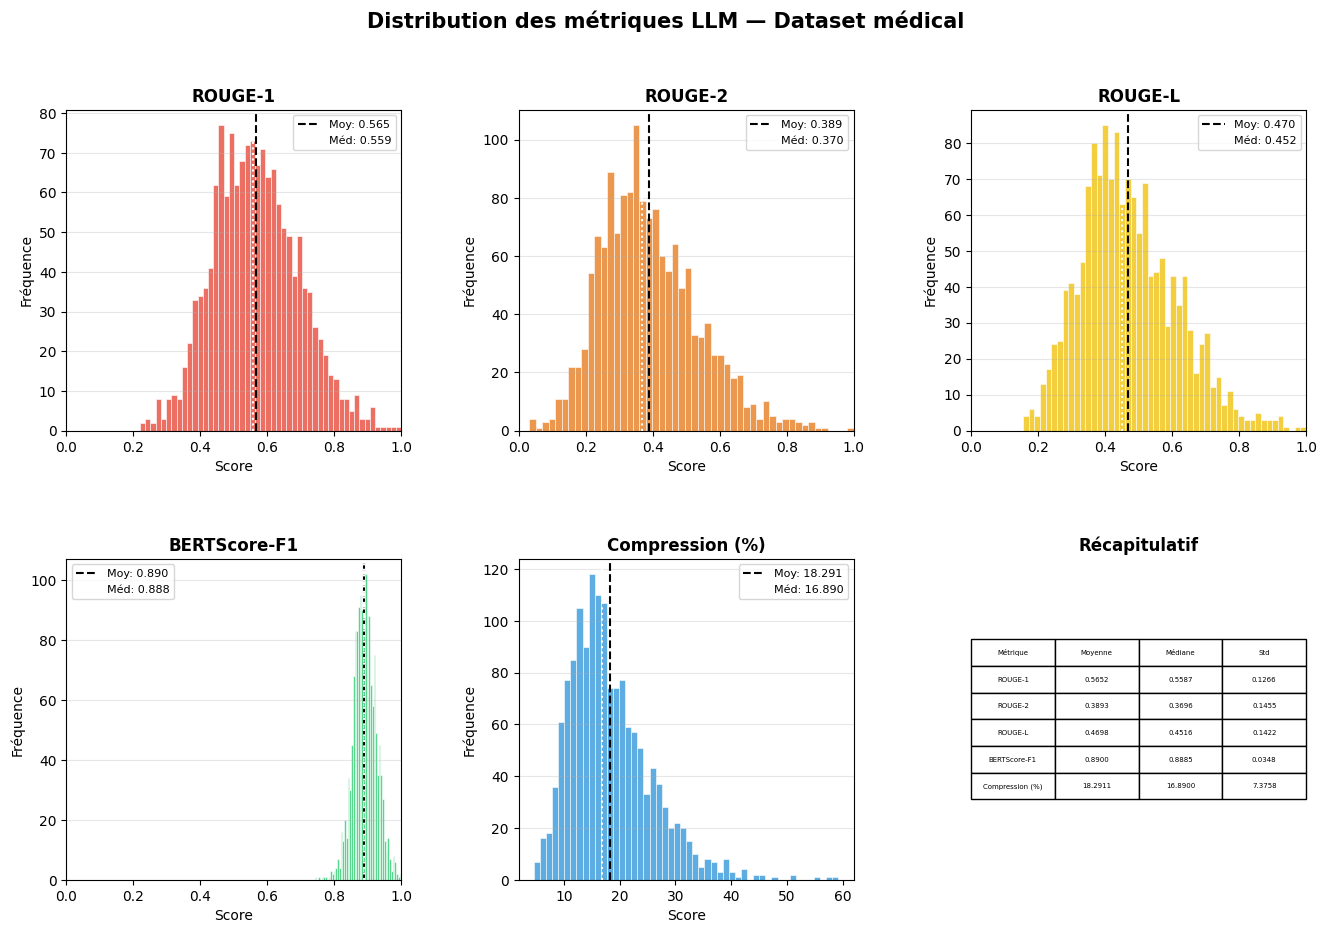

✅ Graphique sauvegardé : /kaggle/working/metrics_distribution.png


In [ ]:
# ============================================================
# CELLULE 7 — Visualisation des distributions de métriques
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Distribution des métriques LLM — Dataset médical', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

metrics_config = [
    ('rouge1',           'ROUGE-1',           '#E74C3C', (0, 1)),
    ('rouge2',           'ROUGE-2',           '#E67E22', (0, 1)),
    ('rougeL',           'ROUGE-L',           '#F1C40F', (0, 1)),
    ('bertscore_f1',     'BERTScore-F1',      '#2ECC71', (0, 1)),
    ('compression_ratio','Compression (%)',   '#3498DB', None),
]

for i, (col, label, color, xlim) in enumerate(metrics_config):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    data = df[df[col] > 0][col]
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Moy: {data.mean():.3f}')
    ax.axvline(data.median(), color='white',  linestyle=':',  linewidth=1.5, label=f'Méd: {data.median():.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)
    if xlim:
        ax.set_xlim(xlim)
    ax.grid(axis='y', alpha=0.3)

# 6ème case : tableau récap
ax_table = fig.add_subplot(gs[1, 2])
ax_table.axis('off')
summary_data = []
for col, label, _, _ in metrics_config:
    d = df[df[col] > 0][col]
    summary_data.append([label, f'{d.mean():.4f}', f'{d.median():.4f}', f'{d.std():.4f}'])

table = ax_table.table(
    cellText=summary_data,
    colLabels=['Métrique', 'Moyenne', 'Médiane', 'Std'],
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(True)
table.scale(1, 1.6)
ax_table.set_title('Récapitulatif', fontweight='bold')

plt.savefig('/kaggle/working/metrics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : /kaggle/working/metrics_distribution.png')